# Loading Dataset

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv('retail.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# Information about the dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

# Data Preprocessing
 

In [7]:
df = df.dropna(subset = ['CustomerID'])
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [35]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [50]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Price,month
count,397884.000000,397884,397884.000000,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453,22.397000,7.612475
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000,1.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000,5.000000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000,8.000000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000,11.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000,12.000000
std,179.331775,NaN,22.097877,1713.141560,309.071041,3.416520


# Data Transformation

In [36]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Price,month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12


In [37]:
df["Price"] = df["Quantity"] * df["UnitPrice"]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Price,month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   Price        397884 non-null  float64       
 9   month        397884 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(1), int64(1), object(4)
memory usage: 31.9+ MB


# EDA

In [39]:
top_selling = df.groupby('Description')['Quantity'].sum().sort_values(ascending = False).head(10)

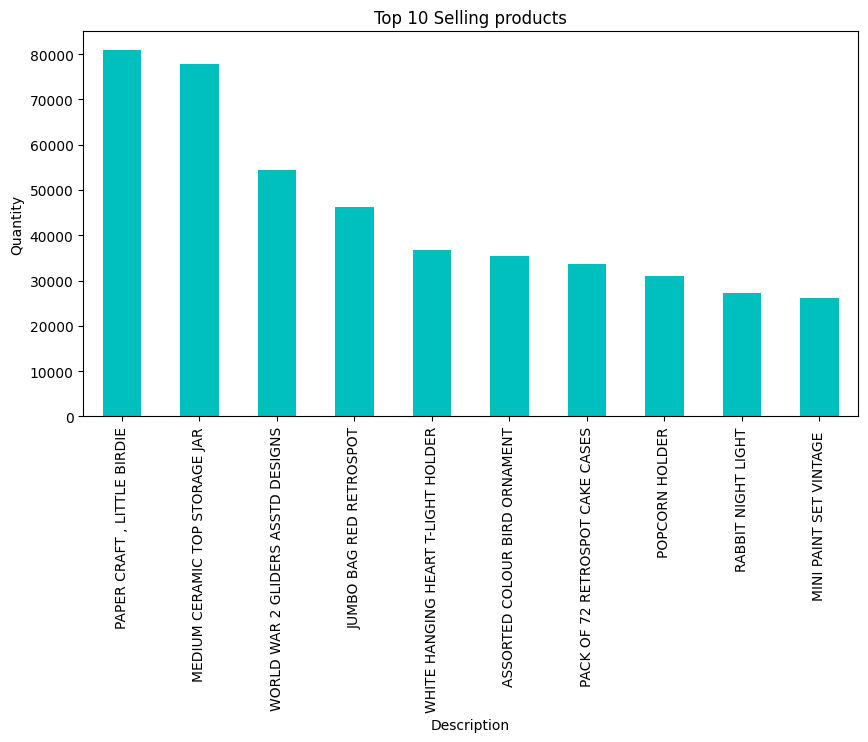

In [40]:
plt.figure(figsize = (10,5))
top_selling.plot(kind = 'bar', color = 'c')
plt.title("Top 10 Selling products")
plt.xlabel('Description')
plt.ylabel('Quantity')
plt.xticks(rotation = 90)
plt.show()

In [41]:
top_cust = df.groupby('CustomerID')['InvoiceNo'].nunique().sort_values(ascending = False).head(20)
top_cust.head(20)

CustomerID
12748.0    209
14911.0    201
17841.0    124
13089.0     97
14606.0     93
15311.0     91
12971.0     86
14646.0     73
16029.0     63
13408.0     62
18102.0     60
13798.0     57
14156.0     55
14527.0     55
16422.0     51
13694.0     50
15061.0     48
16013.0     47
15039.0     47
17450.0     46
Name: InvoiceNo, dtype: int64

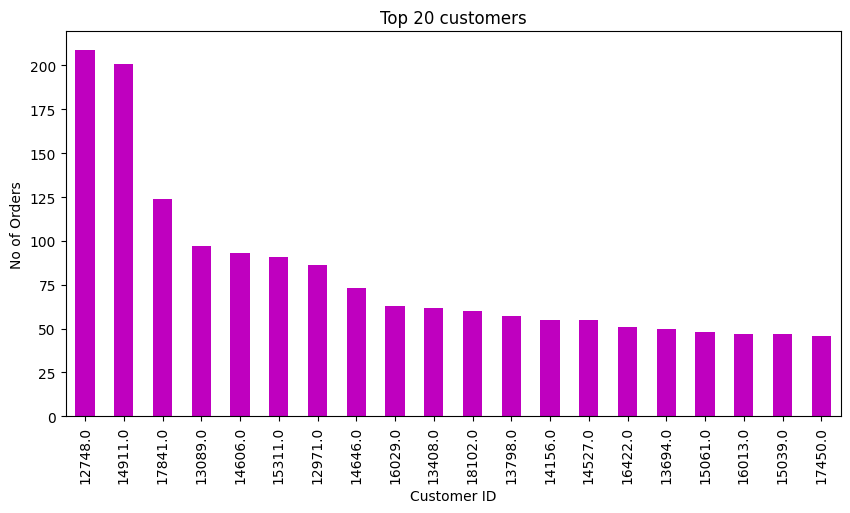

In [42]:
plt.figure(figsize = (10,5))
top_cust.plot(kind = 'bar', color = 'm' )
plt.title("Top 20 customers")
plt.xlabel("Customer ID")
plt.ylabel("No of Orders")
plt.show()

In [43]:
df['month'] = df['InvoiceDate'].dt.month
monthly_sales = df.groupby('month')['Price'].sum().sort_values(ascending = False)
monthly_sales.head(12)

month
11    1161817.380
12    1090906.680
10    1039318.790
9      952838.382
5      678594.560
6      661213.690
8      645343.900
7      600091.011
3      595500.760
1      569445.040
4      469200.361
2      447137.350
Name: Price, dtype: float64

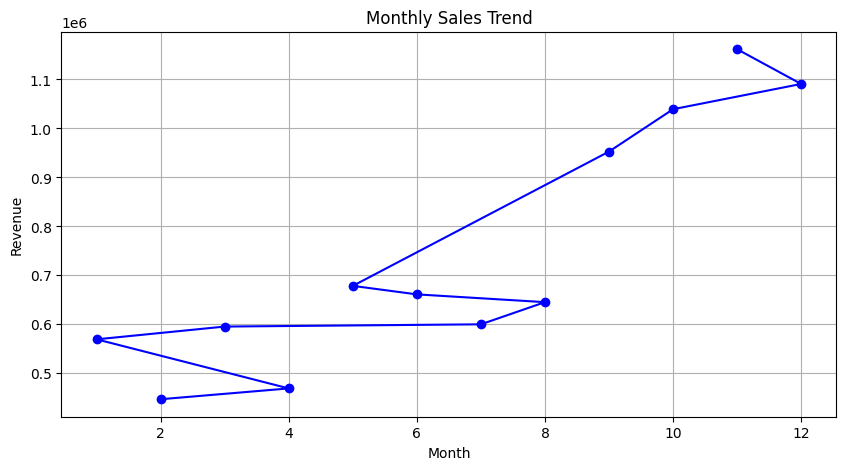

In [44]:
plt.figure(figsize = (10,5))
monthly_sales.plot(marker='o', color = 'b')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid()
plt.show()

# RFM analysis

In [45]:
snapshot_date = (df['InvoiceDate'].max() + pd.Timedelta(days = 1))

In [46]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate' : lambda x : (snapshot_date - x.max()).days,
    'InvoiceNo' : 'count',
    'Price' : 'sum'
})

In [47]:
rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

In [48]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [52]:
rfm['R'] = pd.qcut(
    rfm['Recency'], 4, labels = [4,3,2,1]
)
rfm['F'] = pd.qcut(
    rfm['Frequency'].rank(method = 'first'), 4, labels = [1,2,3,4]
)
rfm['M'] = pd.qcut(
    rfm['Monetary'], 4, labels = [1,2,3,4]
)

In [54]:
rfm['RFM_score'] = (rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str))

In [55]:
rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,182,4310.00,4,4,4,444
12348.0,75,31,1797.24,2,2,4,224
12349.0,19,73,1757.55,3,3,4,334
12350.0,310,17,334.40,1,1,2,112


# Customer Segmentation using K-means

In [57]:
x = rfm[['Recency','Frequency','Monetary']]

In [60]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(
        n_clusters = 4,
        random_state = 42
    ))
])

pipeline.fit(x)

,steps,"[('scaler', ...), ('kmeans', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300


In [61]:
rfm['clusters'] = pipeline.predict(x)